<a href="https://colab.research.google.com/github/Rahulchoudharygi/Assignment-Food-Delivery-Data-Visualization-Portfolio-Day-14/blob/main/Assignment_Food_Delivery_Data_Visualization_Portfolio_(Day_14).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Environment Setup & Data Loading**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('Day14_Food_Delivery_Visualization_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Ensure chronological order for time-series analysis
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print("Dataset Overview:")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head(3)

Dataset Overview:
Total Rows: 360 | Total Columns: 16


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0


**Step 2: Visualization Portfolio (Charts & Interpretations)**
1. Line Plot: Monthly Revenue & Order Volume Trends

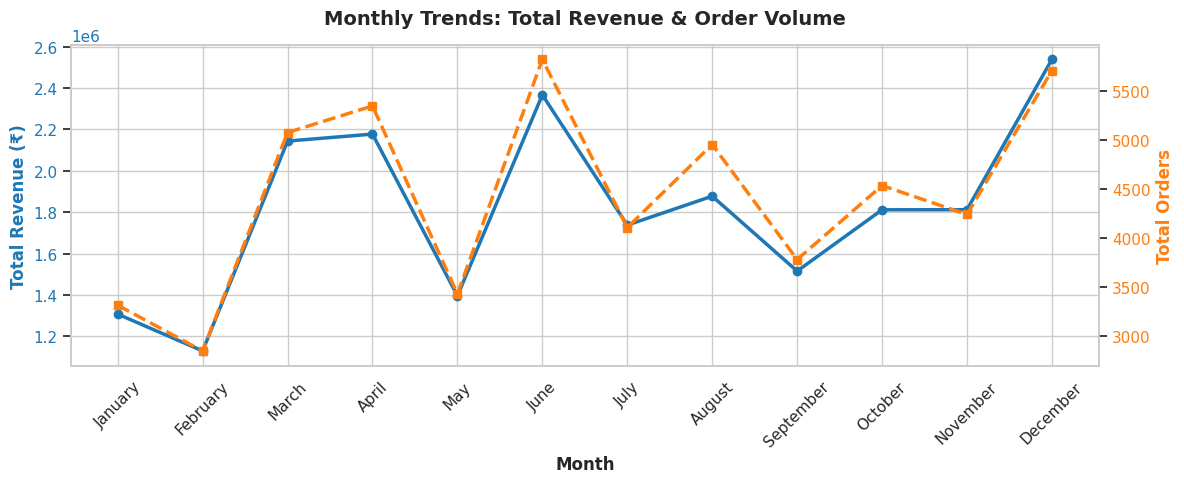

In [18]:
monthly_summary = df.groupby('Month', observed=True)[['Orders', 'Revenue']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Total Revenue (₹)', color=color, fontweight='bold')
line1 = ax1.plot(monthly_summary['Month'], monthly_summary['Revenue'], marker='o', color=color, linewidth=2.5, label='Revenue (₹)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Total Orders', color=color, fontweight='bold')
line2 = ax2.plot(monthly_summary['Month'], monthly_summary['Orders'], marker='s', color=color, linewidth=2.5, linestyle='--', label='Orders')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title('Monthly Trends: Total Revenue & Order Volume', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

2. Bar Chart: Average Order Value & Revenue by Cuisine

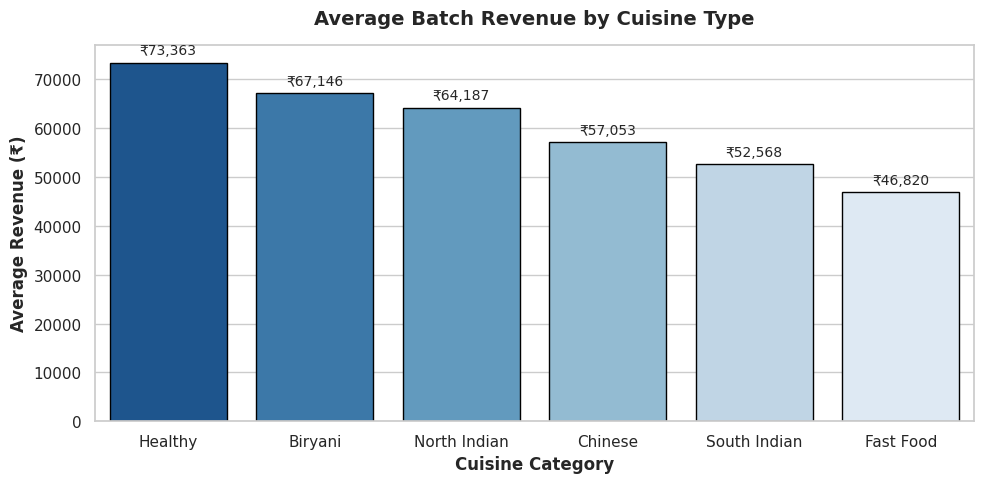

In [19]:
cuisine_perf = df.groupby('Cuisine')[['Revenue', 'Average_Order_Value']].mean().reset_index().sort_values(by='Revenue', ascending=False)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=cuisine_perf,
    x='Cuisine',
    y='Revenue',
    hue='Cuisine',
    palette='Blues_r',
    legend=False,
    edgecolor='black'
)
plt.title('Average Batch Revenue by Cuisine Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cuisine Category', fontweight='bold')
plt.ylabel('Average Revenue (₹)', fontweight='bold')

for p in ax.patches:
    ax.annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

3. Count Plot & Bar Plot: Channel Distribution and Performance

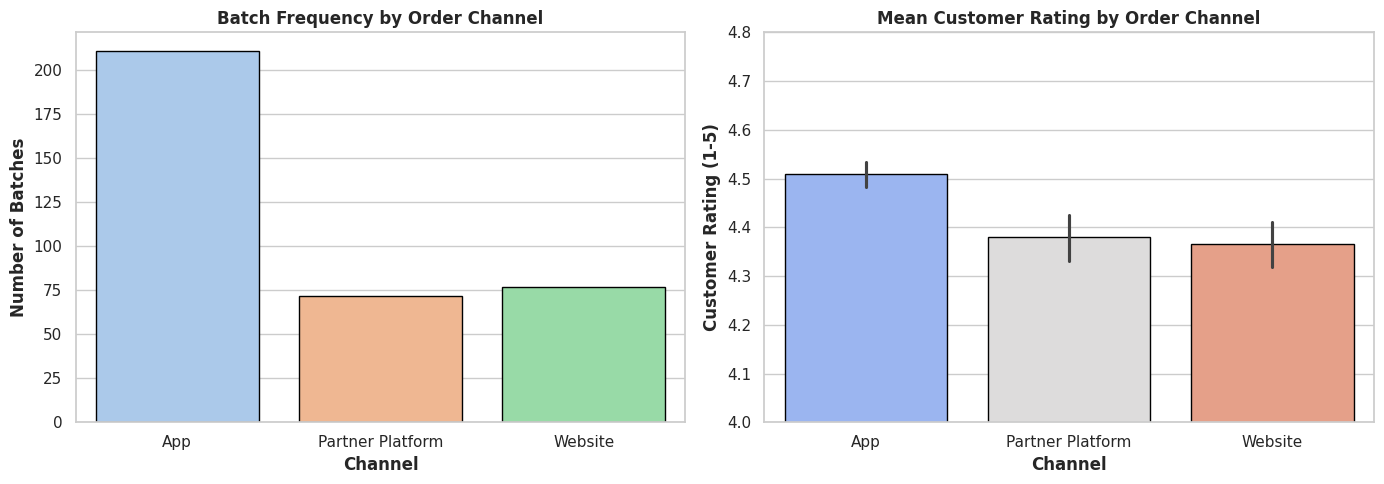

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order count across channels
sns.countplot(
    data=df,
    x='Order_Channel',
    hue='Order_Channel',
    palette='pastel',
    legend=False,
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Batch Frequency by Order Channel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Channel', fontweight='bold')
axes[0].set_ylabel('Number of Batches', fontweight='bold')

# Average rating per channel
sns.barplot(
    data=df,
    x='Order_Channel',
    y='Customer_Rating',
    hue='Order_Channel',
    palette='coolwarm',
    legend=False,
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Mean Customer Rating by Order Channel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Channel', fontweight='bold')
axes[1].set_ylabel('Customer Rating (1-5)', fontweight='bold')
axes[1].set_ylim(4.0, 4.8)

plt.tight_layout()
plt.show()

4. Scatter Plot: Delivery Time vs. Customer Rating by Weather

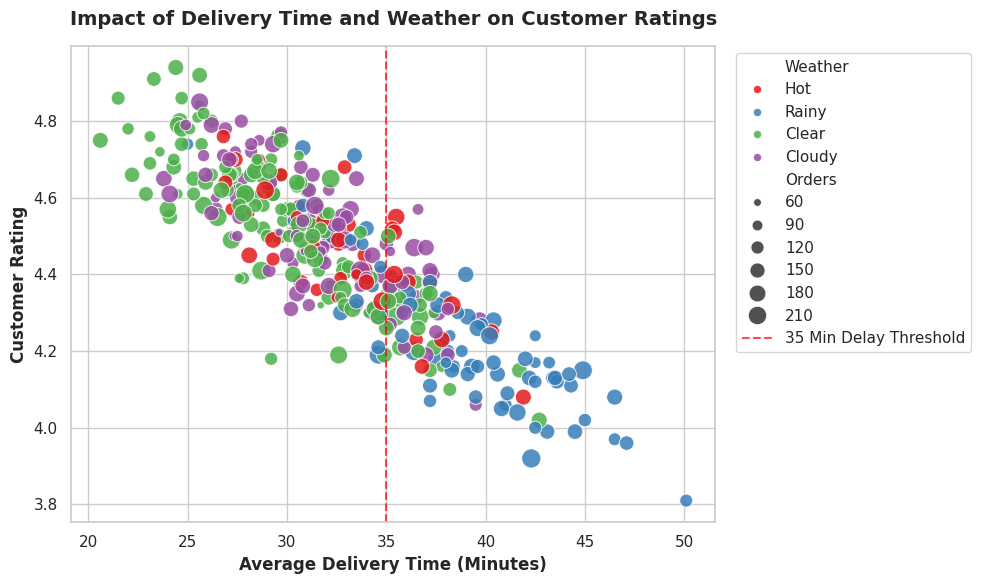

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Avg_Delivery_Minutes',
    y='Customer_Rating',
    hue='Weather',
    size='Orders',
    sizes=(30, 200),
    palette='Set1',
    alpha=0.85
)

plt.axvline(x=35, color='red', linestyle='--', alpha=0.7, label='35 Min Delay Threshold')
plt.title('Impact of Delivery Time and Weather on Customer Ratings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Delivery Time (Minutes)', fontweight='bold')
plt.ylabel('Customer Rating', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

5. Box Plot & Violin Plot: City-Wise Delivery Time & Discount Distributions

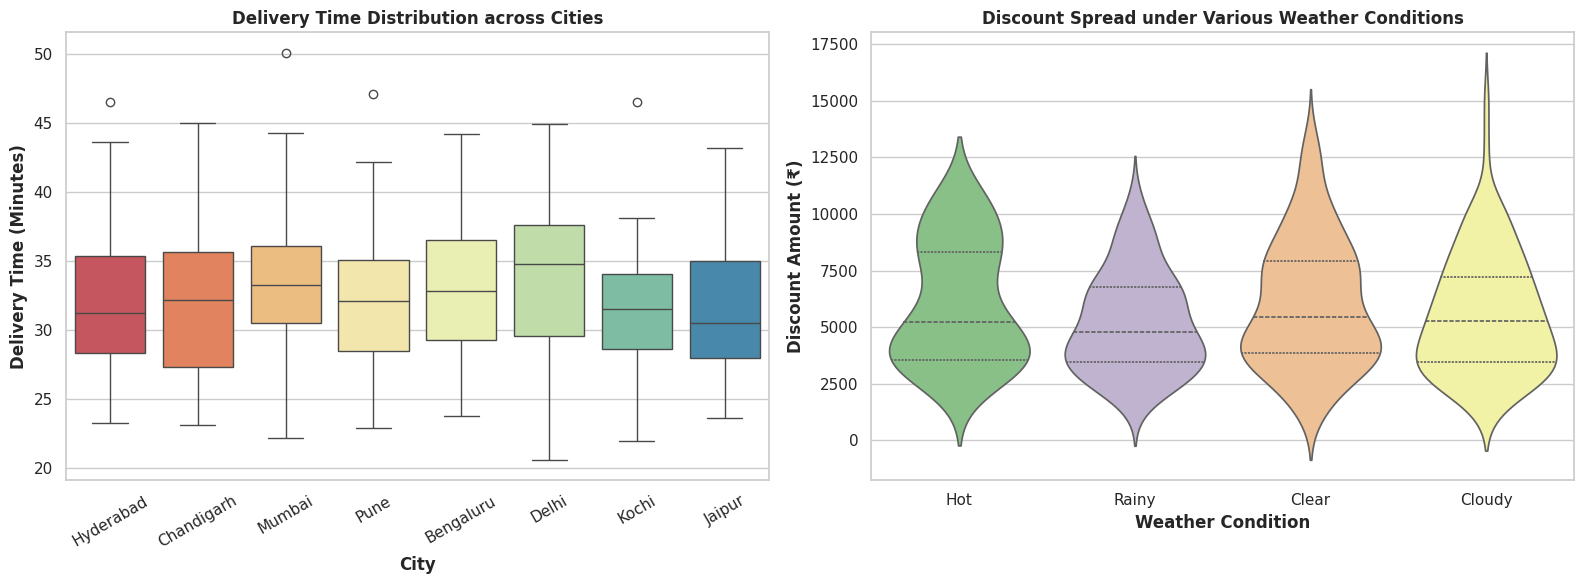

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Delivery Time by City
sns.boxplot(
    data=df,
    x='City',
    y='Avg_Delivery_Minutes',
    hue='City',
    palette='Spectral',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Delivery Time Distribution across Cities', fontsize=12, fontweight='bold')
axes[0].set_xlabel('City', fontweight='bold')
axes[0].set_ylabel('Delivery Time (Minutes)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Violinplot: Discount spread across Weather conditions
sns.violinplot(
    data=df,
    x='Weather',
    y='Discounts',
    hue='Weather',
    palette='Accent',
    inner='quartile',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Discount Spread under Various Weather Conditions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weather Condition', fontweight='bold')
axes[1].set_ylabel('Discount Amount (₹)', fontweight='bold')

plt.tight_layout()
plt.show()

6. Correlation Heatmap: Operational and Financial Metrics

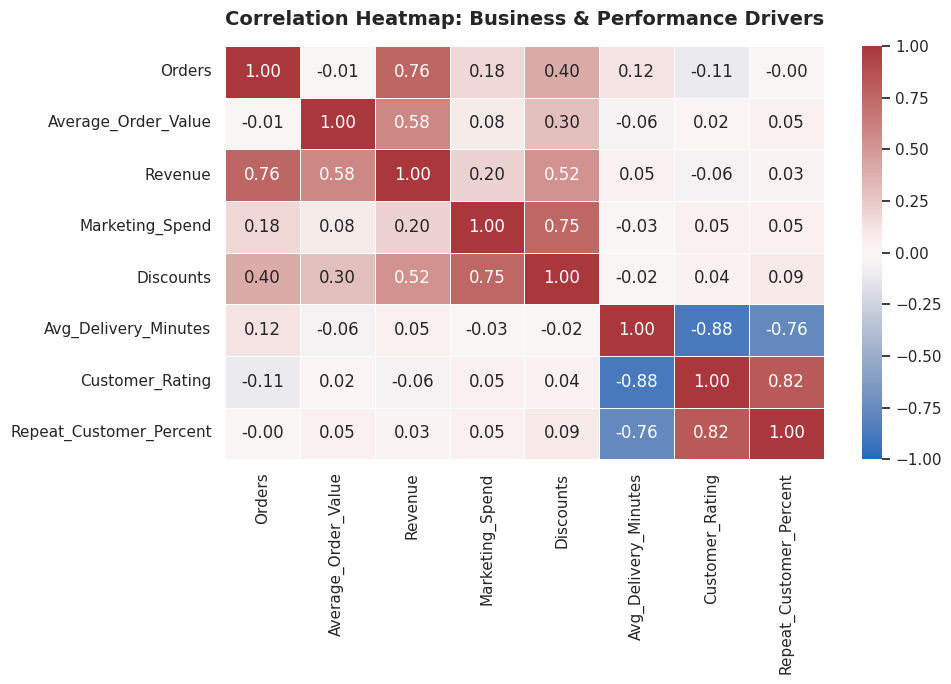

In [23]:
corr_features = [
    'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend',
    'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent'
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap='vlag',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.6
)
plt.title('Correlation Heatmap: Business & Performance Drivers', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()